Data loaded successfully!
Total rows: 1792, Total columns: 13

Column names:
['OBJECTID', 'WUDS_ID', 'NAME', 'CNTY_CODE', 'CNTY_NAME', 'OWNERSHIP', 'GW_SOURCE', 'SW_SOURCE', 'INTCONNECT', 'LAST_DATE', 'PWS_ID', 'SHAPEAREA', 'SHAPELEN']

Number of water systems in Allegheny County: 36


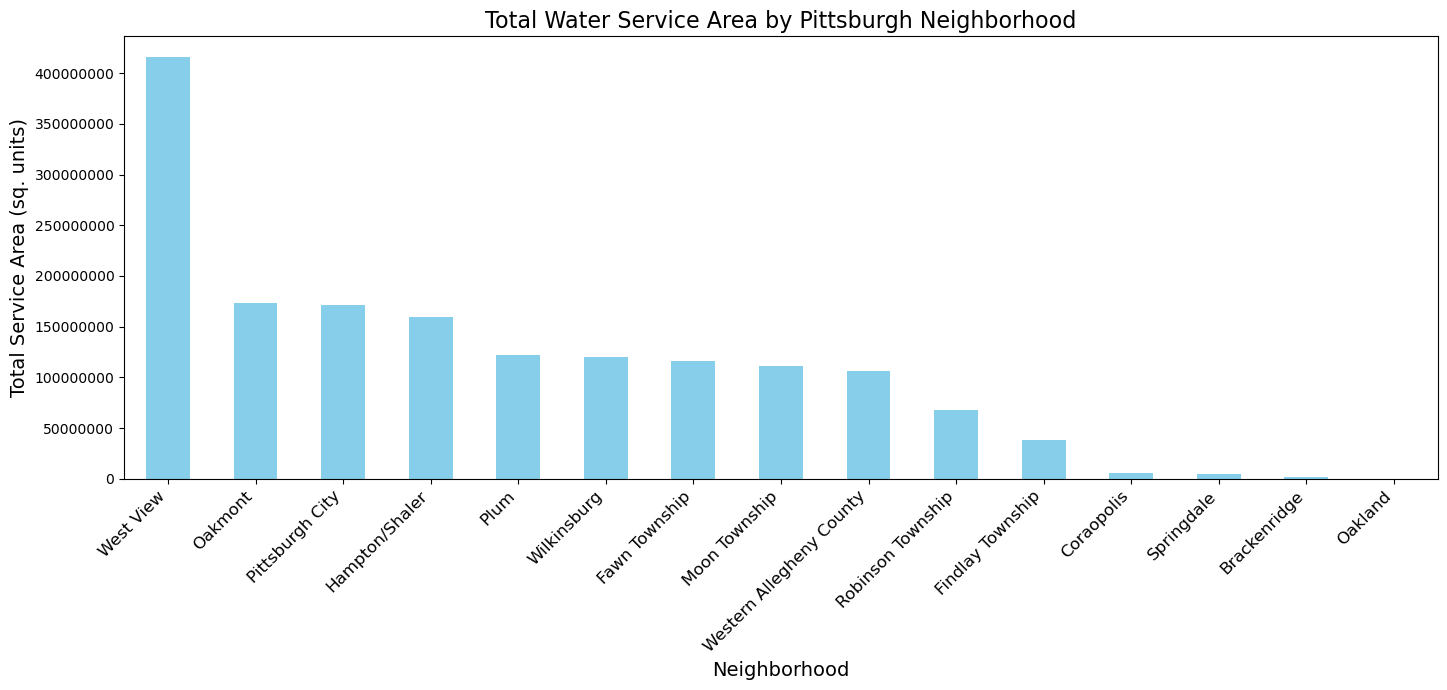


Top 5 Pittsburgh Neighborhoods by Total Water Service Area:
NEIGHBORHOOD
West View          4.154344e+08
Oakmont            1.734880e+08
Pittsburgh City    1.717609e+08
Hampton/Shaler     1.599354e+08
Plum               1.225350e+08
Name: SHAPEAREA, dtype: float64

Sub-metric Explanation:
We use total water service area per neighborhood as a sub-metric for 'best neighborhood'.
Larger service area indicates more extensive and reliable water infrastructure for the community.

Data aggregated by neighborhood, ready for final combined scoring.


In [3]:
# Import required libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Load the public water supplier service area dataset
df = pd.read_csv("../data/public_water_systems_-_public_water_supplier_service_areas.csv")

# Verify successful data loading with basic overview
print("Data loaded successfully!")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
df.head()

# Filter dataset to Allegheny County (Pittsburgh's home county)
# FIX: Use .copy() to eliminate SettingWithCopyWarning
pgh_water = df[df['CNTY_NAME'] == 'Allegheny'].copy()
print(f"\nNumber of water systems in Allegheny County: {len(pgh_water)}")

# Map water suppliers to their corresponding Pittsburgh neighborhoods
neighborhood_mapping = {
    'AMER WATER CO PITTSBURGH DIST': 'Downtown/Oakland',
    'PITTSBURGH W AND S AUTH': 'Pittsburgh City',
    'WILKINSBURG PENN JT WATER AUTH': 'Wilkinsburg',
    'WEST VIEW MUNI AUTH': 'West View',
    'OAKMONT BORO MUNI AUTH': 'Oakmont',
    'HAMPTON SHALER WATER AUTH': 'Hampton/Shaler',
    'PLUM BORO MUNI AUTH': 'Plum',
    'ROBINSON TWP MUNI AUTH': 'Robinson Township',
    'WESTERN ALLEGHENY CNTY MUNI AU': 'Western Allegheny County',
    'BRACKENRIDGE BORO WATER': 'Brackenridge',
    'SPRINGDALE BORO WATER DEPT': 'Springdale',
    'FINDLAY TWP MUNI AUTH': 'Findlay Township',
    'VA HEALTHCARE SYSTEM HEINZ': 'Oakland',
    'CORAOPOLIS WATER AND SEWER AUTHORITY': 'Coraopolis',
    'MOON TWP MUNI AUTH': 'Moon Township',
    'FAWN FRAZER JT WATER AUTH': 'Fawn Township',
    'EAST PITTSBURGH BORO WATER': 'East Pittsburgh'
}

# Add neighborhood column to the dataset (warning-free now)
pgh_water['NEIGHBORHOOD'] = pgh_water['NAME'].map(neighborhood_mapping)

# Aggregate total water service area by neighborhood
neighborhood_water = pgh_water.groupby('NEIGHBORHOOD')['SHAPEAREA'].sum().sort_values(ascending=False)

# Create visualization of water service area by neighborhood
plt.figure(figsize=(14, 7))
neighborhood_water.plot(kind='bar', color='skyblue')
plt.title('Total Water Service Area by Pittsburgh Neighborhood', fontsize=16)
plt.xlabel('Neighborhood', fontsize=14)
plt.ylabel('Total Service Area (sq. units)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Save plot to images folder
plt.savefig("../images/water_by_neighborhood.png", dpi=300, bbox_inches='tight')
plt.show()

# Print analysis results and sub-metric explanation
print("\nTop 5 Pittsburgh Neighborhoods by Total Water Service Area:")
print(neighborhood_water.head())
print("\nSub-metric Explanation:")
print("We use total water service area per neighborhood as a sub-metric for 'best neighborhood'.")
print("Larger service area indicates more extensive and reliable water infrastructure for the community.")
print("\nData aggregated by neighborhood, ready for final combined scoring.")